# Could a mixed build ever beat committing to one technology?

**The question.** The companion notebook (`mc_cost_trajectories.ipynb`) assumes *winner-take-all*:
in every simulated future, the entire US nuclear build program goes to whichever technology —
traditional large reactors or small modular reactors (SMRs) — is cheaper in that future. Its
fragmentation figure shows that *splitting the program 50/50* is always more expensive. But that
result was obtained under two assumptions that stack the deck against mixing:

1. **Zero cross-technology spillover** — building large reactors taught SMR vendors nothing, and
   vice versa. If experience *did* transfer between the two technologies, an intriguing strategy
   opens up: build some of the initially-cheaper technology first, let that experience spill over,
   and switch once the other technology has been pulled down its cost curve.
2. **Perfectly linked draws** — the two technologies' 2030 cost estimates were drawn at the
   *same percentile* of their published ranges, and so were their learning rates. That wipes out
   the economically interesting tension. Here both pairs are drawn **independently**, subject
   only to the two orderings every real SMR proposal respects: the SMR starts *more expensive*
   (`boak_smr > boak_large`) and *learns faster* (`lr_smr > lr_large`). Every drawn future is
   therefore a genuine instance of the SMR bet — pay more at the start, descend faster — with
   the sizes of the cost gap and the learning-rate gap free to vary independently.

**This notebook relaxes both assumptions and then actively searches for a winning mixed strategy.**
For every simulated future we hand an optimizer a 20-element dial — the SMR share of each year's
construction, 2031–2050 — and ask it to minimize the total (discounted, financing-inclusive) cost
of hitting that future's deployment schedule. If even a motivated optimizer, granted up to 30%
cross-technology spillover in each direction and independently varying cost and learning-rate
gaps, cannot beat the better of the two pure strategies, then winner-take-all is validated under
much weaker assumptions than before. If mixing *does* win somewhere, the parameter-space maps in
S8 show exactly where — and either way they chart where the SMR-vs-large decision boundary runs
through the (cost gap, learning-rate gap) plane.

**Discipline reminder** (same as the companion notebook): every cost trajectory here is
**conditional on an imposed deployment schedule** — these are *"what would it cost if we built
this much"* curves, never predictions of what will be built.

In [1]:
import json
import os
import zlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize

# --- Paths: anchored to this notebook's folder, never the launch directory ---
NB_DIR = Path.cwd() if Path.cwd().name == "mc" else Path("z-ethan/mc").resolve()
assert (NB_DIR / "pris_loader.py").exists(), f"notebook folder not found from {Path.cwd()}"
REPO_ROOT = NB_DIR.parent.parent               # the ReEDS-nuclear-learning fork
EXPORTS = NB_DIR / "exports" / "mixed_build"   # this notebook's analysis exports
FIGURES = NB_DIR / "figures"
for d in (EXPORTS, FIGURES):
    d.mkdir(parents=True, exist_ok=True)

import sys
if str(NB_DIR) not in sys.path:                # make `import pris_loader` work from any launch dir
    sys.path.insert(0, str(NB_DIR))
sys.path.insert(0, str(NB_DIR.parent))         # z-ethan root: the house plot style
import plotstyle as ps
ps.apply()

# --- Reproducibility: one master seed, independent named streams (same policy as the
# companion notebook; every stream name here is prefixed "mixopt/" so no stream can
# collide with the companion notebook's draws) ---
MASTER_SEED = 20260715

def rng_stream(name):
    """An independent, reproducible random generator tied to a label."""
    return np.random.default_rng(np.random.SeedSequence((MASTER_SEED, zlib.crc32(name.encode()))))

# --- Analysis switches ---
# The anchor-cost and learning-rate draws are INDEPENDENT between the technologies,
# conditioned on the two orderings every real SMR proposal respects (S4):
#   boak_smr > boak_large   (the SMR starts more expensive)
#   lr_smr   > lr_large     (the SMR learns faster)
# The companion notebook's comonotone (same-percentile) draw is retained only as the
# QA-G continuity limit.

# Cross-technology spillover: each simulated future draws two fractions uniformly on
# [0, X_SPILL_MAX] — how much of one technology's US build experience also teaches the
# other technology's vendors (large->SMR and SMR->large are drawn independently).
X_SPILL_MAX = 0.30

# The US historical large-reactor fleet does NOT flow to SMRs through the drawn spillover:
# the empirical SMR learning-rate range already embeds any benefit from those prior builds
# (the companion notebook's D8' convention). Only post-2030 program builds spill over.
HIST_CROSS_TECH = False

COPULA_SET = "moderate"                        # lr <-> boak correlation set (as companion)

# Optimizer-funnel controls (S6): a draw goes to the expensive free optimizer if any mixed
# candidate in the cheap vectorized screen comes within EPS_FLAG of the best pure corner;
# AUDIT_FRAC of draws are polished regardless, to verify the screen misses nothing.
EPS_FLAG = 0.005
AUDIT_FRAC = 0.03
TOL_WIN = 0.001          # a mixed strategy "wins" if it beats the best corner by > 0.1%

# Draw counts (environment overrides let test runs stay cheap without editing the notebook)
N_DRAWS_OPT = int(os.environ.get("MIXOPT_DRAWS", 10000))        # per schedule, main analysis
REP_SCHED = "McKinsey GEP 2025"                # representative schedule (worked example, QA)

# --- Model frame (identical to the companion notebook) ---
YEARS = np.arange(2024, 2051)
T = len(YEARS)
def yi(y):
    """Index of calendar year y in the YEARS grid."""
    return int(np.where(YEARS == y)[0][0])

ANCHOR = 2030
N_BOAK_UNITS = 2.0
OMEGA = 1.0 / 3.0
CES_RHO_GRID = np.array([-1.0, 0.0, 1.0])   # symmetric since 2026-08-06 (companion S1)
TECH = {
    "large": {"unit_gw": 1.000, "lr_lo": 0.03, "lr_hi": 0.12,
              "boak_lo": 5250.0, "boak_hi": 7750.0},
    "smr":   {"unit_gw": 0.300, "lr_lo": 0.03, "lr_hi": 0.16,
              "boak_lo": 5500.0, "boak_hi": 10000.0},
}
UNIT_FOREIGN_GW = 1.0
U_GRID = np.linspace(0.0, 1.0, 21)

# The optimizer's decision variable: SMR share of each build year 2031-2050
BUILD_YEARS = np.arange(2031, 2051)
N_P = len(BUILD_YEARS)                          # 20
BUILD_SLICE = slice(yi(2031), yi(2050) + 1)

print(f"notebook dir : {NB_DIR}")
print(f"switches     : x_spill_max={X_SPILL_MAX}, copula={COPULA_SET}, "
      f"draws/schedule={N_DRAWS_OPT} (independent draws, ordered: SMR pricier, SMR faster-learning)")
print(f"funnel       : eps_flag={EPS_FLAG:.1%}, audit={AUDIT_FRAC:.0%}, win tolerance={TOL_WIN:.1%}")

notebook dir : C:\Users\ethan\code\research\ReEDS-nuclear-learning\z-ethan\mc
switches     : x_spill_max=0.3, copula=moderate, draws/schedule=10000 (independent draws, ordered: SMR pricier, SMR faster-learning)
funnel       : eps_flag=0.5%, audit=3%, win tolerance=0.1%


C:\Users\ethan\code\research\ReEDS-nuclear-learning\z-ethan\plotstyle.py:1: SyntaxWarning: invalid escape sequence '\m'
  """z-ethan house plot style — the normative formatting standard (2026-08-17).


## What is different from the companion notebook — and how to turn each change off

| Change | What it does | Why | "Off" setting |
|---|---|---|---|
| **Independent, ordered draws** | Anchor costs and learning rates are drawn independently between the technologies, conditioned on `boak_smr > boak_large` and `lr_smr > lr_large`. Published ranges are unchanged (truncated by the conditioning). | The companion's same-percentile draw pinned both gaps to one dial; here the cost gap and the learning-rate gap vary freely — every draw is a genuine "pay more now, learn faster" SMR bet. | The companion's comonotone draw is retained as the QA-G limit |
| **Cross-technology spillover** | Two drawn fractions `x_ls` (large→SMR) and `x_sl` (SMR→large), each U(0, 30%), feed one technology's post-2030 US builds into the other's discounted cross-firm learning channel. | The only mechanism by which "build cheap traditional first" could ever pay off. | Force both to 0 (the S8 check does this) |
| **Optimizer instead of winner-take-all** | A per-future optimizer chooses the SMR share of every build year to minimize discounted financed program cost. | Tests *all* mixed strategies, not just 50/50. | The two pure strategies are always in the candidate set |

Everything else — the six deployment schedules, the PRIS-based international stocks, the
learning-curve engine, the construction-duration model, and the ReEDS financing replication —
is **ported unchanged** from the companion notebook, and the S9 QA cells assert that at the
"off" settings this notebook reproduces the companion engine bit-for-bit.

## The six deployment schedules

Read from `inputs/nuclear_learning/US_SCHEDULES.csv` — the single source of truth exported by
the companion notebook (this notebook deliberately does *not* redefine them). Values are
capacity indices (100 = the 97 GW 2024 fleet); the working GW basis everywhere is the index
read as literal GW **minus a flat 3 GW**, exactly as in the companion notebook and the ReEDS
mandate files.

In [2]:
US_GW_2024 = 97.0
OFFSET_GW = 3.0

US_SCHEDULES_CSV = REPO_ROOT / "inputs" / "nuclear_learning" / "US_SCHEDULES.csv"
_sched_df = pd.read_csv(US_SCHEDULES_CSV, comment="#", index_col="year")

# Display names for the machine tokens in the CSV, in fixed ascending-ambition order
TOKEN_NAME = {"eia_aeo_high": "EIA 2026 AEO high", "abou_jaoude": "Abou-Jaoude mod",
              "iaea_high": "IAEA high", "mckinsey": "McKinsey GEP 2025",
              "cop28": "COP28 tripling pledge", "eo2025": "2025 EO"}
assert set(_sched_df.columns) == set(TOKEN_NAME), "US_SCHEDULES.csv columns changed"
assert list(_sched_df.index) == list(YEARS), "US_SCHEDULES.csv year grid changed"

US_SCHEDULES = {TOKEN_NAME[tok]: _sched_df[tok].to_numpy(float) for tok in TOKEN_NAME}
SCHED_ORDER = list(US_SCHEDULES)
SCEN_TOKEN = {v: k for k, v in TOKEN_NAME.items()}

print("schedules loaded (2050 capacity in working GW basis):")
for name in SCHED_ORDER:
    print(f"  {name:22s} {US_SCHEDULES[name][-1] - OFFSET_GW:5.0f} GW")

schedules loaded (2050 capacity in working GW basis):
  EIA 2026 AEO high        114 GW
  Abou-Jaoude mod          131 GW
  IAEA high                169 GW
  McKinsey GEP 2025        197 GW
  COP28 tripling pledge    297 GW
  2025 EO                  397 GW


## Historical and international experience (ported from companion S3)

The learning engine needs to know how much nuclear construction experience exists outside the
US program: the IAEA's PRIS reactor database provides every unit ever grid-connected, the
under-construction pipeline, and region-by-region growth projections. All of this is identical
to the companion notebook — see its S3 for the full plain-language walkthrough.

In [3]:
# Ported verbatim from mc_cost_trajectories.ipynb S3 (regional milestones, PRIS load,
# retirement identity, committed pipeline, historical stocks).
REGION_MILESTONES = {
    "CA":  (12.7, 12.7, 12.7, 18.8, 23.0, 30.0, 63.7),
    "SAM": (5.1, 5, 5, 8, 11, 8, 20),
    "WEU": (95.4, 86, 92, 81, 114, 68, 136),
    "EEU": (53.6, 57, 57, 58, 82, 68, 103),
    "AF":  (1.9, 4, 5, 7, 12, 12, 30),
    "WA":  (5.8, 11, 11, 12, 20, 15, 35),
    "SA":  (11.1, 18, 22, 25, 43, 45, 85),
    "CEA": (94.5, 136, 144, 215, 264, 242, 328),
    "SEA": (0, 0, 0, 3, 7, 4, 18),
    "OC":  (0, 0, 0, 0, 0, 0, 2),
}
THETA_KV = {"CA": 0.28, "SAM": 0.14, "WEU": 0.17794117647, "EEU": 0.1325, "AF": 0.16688725490,
            "WA": 0.13375, "SA": 0.185, "CEA": 0.135, "SEA": 0.16583333, "OC": 0.18}
REGIONS = list(THETA_KV.keys())

import pris_loader as pl

PRIS_UNITS = pl.load_units(str(NB_DIR / "rds2_2025_units.csv"))
_milestones_2024 = {r: REGION_MILESTONES[r][0] for r in REGIONS} | {"US": US_GW_2024}
_issues = pl.validate_units(PRIS_UNITS[PRIS_UNITS["status"] == "operational"], _milestones_2024)
assert not _issues, _issues

FLEET = PRIS_UNITS[PRIS_UNITS["status"] == "operational"]
UC_UNITS = PRIS_UNITS[PRIS_UNITS["status"] == "under construction"]

def retirement_flow_gw(key, life_yr):
    """GW retiring per model year, from each unit's real grid-connection date + a lifetime rule."""
    return pl.retirement_schedule(FLEET, pd.Index(YEARS), lifetime_years=life_yr,
                                  region=key).to_numpy()

PIPE_END = 2030   # pipeline's real visibility horizon; structurally zero after 2030 (mc S3)
PIPELINE_GW = {r: pl.committed_pipeline(UC_UNITS[UC_UNITS["region"] == r],
                                        pd.Index(np.arange(2025, PIPE_END + 1)),
                                        lead_time_months=72).to_dict()
               for r in REGIONS}

# Under-construction units are excluded: 5 carry PLANNED grid dates (not completed experience)
_ever = PRIS_UNITS[(PRIS_UNITS["status"] != "under construction")
                   & PRIS_UNITS["grid_connection"].notna()]
HIST_UNITS = {r: int((_ever["region"] == r).sum()) for r in REGIONS + ["US"]}

US_LICENSE_LIFE = 80.0
ONE_FACTOR_DELTA = 0.0

print(f"PRIS fleet loaded: {len(FLEET)} operational, {len(UC_UNITS)} under construction")

PRIS fleet loaded: 417 operational, 62 under construction


In [4]:
# Ported verbatim from companion S3: foreign stocks on the u grid, plus this notebook's
# per-schedule GROSS GW ADDITIONS (the quantity the optimizer splits between technologies).
def net_path_gw(region, u):
    """Regional net capacity path: interpolate the 2024/2030/2040/2050 milestones, positioned
    between Low and High by the global deployment draw u."""
    c = REGION_MILESTONES[region]
    vals = [c[0], c[1] + u*(c[2]-c[1]), c[3] + u*(c[4]-c[3]), c[5] + u*(c[6]-c[5])]
    return np.interp(YEARS, [2024, 2030, 2040, 2050], vals)

def gross_additions_gw(region, u):
    """The retirement identity: builds = max(0, capacity change + retirements); the committed
    pipeline REPLACES the interpolated path through PIPE_END = 2030 (real units; structurally
    zero after 2030, so it only shapes the pre-anchor record - see mc_cost_trajectories S3)."""
    dnet = np.diff(net_path_gw(region, u), prepend=net_path_gw(region, u)[0])
    ret = retirement_flow_gw(region, 65.0 + 5.0*u)   # IAEA-calibrated lives, 65+5u (mc S3; 2026-08-05)
    g = np.clip(dnet + ret, 0.0, None)
    pipe_mask = YEARS <= PIPE_END
    g[pipe_mask] = [PIPELINE_GW[region].get(int(y), 0.0) for y in YEARS[pipe_mask]]
    return g

# Foreign stocks on the u grid (companion S3): unsplit, 1-GW basis - the engine's cross-firm
# channel does not distinguish designs (companion S5 Step 5). The IAEA SMR-share split of the
# foreign fleet lives in the main notebook's S14 own-routing sensitivity, not in any engine.
REGION_STOCK = {}
for r in REGIONS:
    m_a = np.empty((len(U_GRID), T))
    for gi, u in enumerate(U_GRID):
        flow = gross_additions_gw(r, u)
        flow = flow.copy(); flow[YEARS <= ANCHOR] = 0.0
        m_a[gi] = np.cumsum(flow) / UNIT_FOREIGN_GW
    REGION_STOCK[r] = m_a

# US gross GW added per year under each schedule, counted from the 2030 anchor. This is the
# pie the optimizer divides: GW_ADD[sched][t] * p(t) goes to SMRs, the rest to large reactors.
US_RET = retirement_flow_gw("US", US_LICENSE_LIFE)
GW_ADD = {}
for name in SCHED_ORDER:
    cap = US_SCHEDULES[name] - OFFSET_GW
    dnet = np.diff(cap, prepend=cap[0])
    flow = np.clip(dnet + US_RET, 0.0, None)
    flow[YEARS <= ANCHOR] = 0.0
    GW_ADD[name] = flow

print("total post-2030 gross additions per schedule (GW):")
for name in SCHED_ORDER:
    print(f"  {name:22s} {GW_ADD[name].sum():6.1f} GW over {int((GW_ADD[name] > 0).sum())} build years")

total post-2030 gross additions per schedule (GW):
  EIA 2026 AEO high        20.7 GW over 15 build years
  Abou-Jaoude mod          36.4 GW over 20 build years
  IAEA high                75.7 GW over 20 build years
  McKinsey GEP 2025       103.4 GW over 20 build years
  COP28 tripling pledge   203.4 GW over 20 build years
  2025 EO                 303.4 GW over 20 build years


## The learning-curve engine, extended with cross-technology spillover

The engine is the companion notebook's (S5 there, with the full D1–D12 derivation): each
technology's overnight capital cost falls as its **own-design** experience (full learning rate)
and its **cross-firm** experience (other vendors + θ·s-weighted international builds, discounted
to ⅓ strength) accumulate, anchored so the 2030 cost equals the drawn estimate exactly.

**Companion-identical (2026-08-06):** the cross-technology term this notebook pioneered —
a drawn fraction `x` of the other technology's **domestic program** joining the cross-firm
channel,

$$A_B(t) \mathrel{+}= x \cdot N_A(t)$$

— was adopted into the companion engine (its S5 Step 5′). International experience stays in the
cross-firm channel, unsplit across technologies: the Kim & Verdolini flows are normalized to the
domestic inter-firm citation baseline (companion Step 5), so ω prices the firm wall and θ the
national border — and foreign units of both technologies are already inside the unsplit
θ-weighted stock, which is why `x` scales no foreign term. Cross-technology experience learns at
⅓ strength, which is what the cross-firm channel encodes. With the cross-tech arguments off, the
engine is bit-for-bit the companion's (asserted in QA-A). The historical pre-2030 US fleet stays
excluded from the cross-tech channel (the S1 switch `HIST_CROSS_TECH`): the SMR learning-rate
evidence already embeds it.

In [5]:
H_ALL_W = sum(THETA_KV[r]*HIST_UNITS[r] for r in REGIONS)   # theta-weighted historical foreign stock

def lag1(a):
    """One-year completion lag along the time axis: the stock ENTERING year t is the builds
    completed through t-1. Cumulative arrays stay end-of-year for accounting; the lag is
    applied here, at the pricing boundary - without it the first post-anchor cohort would
    price on its own not-yet-built units (below BOAK). Companion-identical (mc S5)."""
    a = np.asarray(a, float)
    out = np.zeros_like(a)
    out[..., 1:] = a[..., :-1]
    return out

OTHER_TECH = {"large": "smr", "smr": "large"}
X_IN_COL = {"large": "x_sl", "smr": "x_ls"}     # incoming cross-tech fraction, per receiving tech

def intl_stock(world):
    """Theta-weighted foreign post-anchor stock, (n_draws, T), UNLAGGED. Unsplit across
    technologies: the engine's cross-firm channel does not distinguish designs (companion
    S5 Step 5). It depends only on the drawn global-deployment position u, so callers that
    evaluate many share profiles for the same worlds compute it once and pass it back in
    (the optimizer's hot loop)."""
    n = len(world)
    u_r = np.repeat(world["u"].values[:, None], len(REGIONS), axis=1)
    if ONE_FACTOR_DELTA > 0:
        u_r = np.clip(u_r + rng_stream("one_factor_noise").uniform(
            -ONE_FACTOR_DELTA, ONE_FACTOR_DELTA, (n, len(REGIONS))), 0, 1)
    gi = np.clip(np.rint(u_r * (len(U_GRID)-1)).astype(int), 0, len(U_GRID)-1)
    S = np.zeros((n, T))
    for j, r in enumerate(REGIONS):
        S += THETA_KV[r] * REGION_STOCK[r][gi[:, j], :]
    return S

def experience_channels(world, tech, n_us, n_oth=None, x_in=None, S_KV=None):
    """The two experience stocks O_d(t) (own) and A_d(t) (cross-firm), each (n_draws, T).
    Companion-identical math (mc S5): international experience enters the CROSS-FIRM
    channel at weight s*theta, unsplit across technologies (the K&V flows are normalized
    to the domestic inter-firm citation baseline - omega prices the firm wall, theta the
    border). Two hot-loop conveniences:
      x_in:  override for the incoming cross-tech fraction (scalar or (n_draws,)); None ->
             the drawn world column (x_sl into large, x_ls into SMR). Used by the x_zero
             sensitivity and QA.
      S_KV:  optional precomputed intl_stock(world) array (pure caching, no change in values).
    n_oth is the OTHER technology's cumulative post-anchor US units, (T,) or (n_draws, T).
    """
    n = len(world)
    if S_KV is None:
        S_KV = intl_stock(world)
    skv = lag1(S_KV)                                     # stock entering year t (built thru t-1)
    N_us = lag1(np.broadcast_to(np.asarray(n_us, float), (n, T)))
    conv = world["conv_full"].values[:, None].astype(float)
    m = world["n_vendors"].values[:, None].astype(float)
    s = world["s"].values[:, None]
    # US historical fleet counts toward LARGE only (companion D8'): crediting the ~140-unit
    # LWR stock to SMRs would double-count what the empirical SMR learning-rate range embeds.
    hist_us = HIST_UNITS["US"] if tech == "large" else 0.0
    own0 = N_BOAK_UNITS + conv*hist_us/m
    own = own0 + N_us/m
    oth = (m-1.0)*own0 + N_us*(m-1.0)/m \
          + s*(conv*H_ALL_W + skv)
    if n_oth is not None:
        x = np.asarray(world[X_IN_COL[tech]].values if x_in is None else x_in, float)
        if x.ndim == 1:
            x = x[:, None]
        N_oth = lag1(np.broadcast_to(np.asarray(n_oth, float), (n, T)))  # completed units only
        oth = oth + x * N_oth                            # the cross-technology spillover term
    return own, oth

CES_EPS = 1e-8

def occ_paths_ces(world, tech, n_us, n_oth=None, x_in=None, ces_rho=None, S_KV=None):
    """Production OCC engine (companion D11/D12, ported verbatim; the cross-tech/caching
    arguments just pass through to experience_channels). Returns $/kW (2022 USD), (n_draws, T)."""
    own, oth = experience_channels(world, tech, n_us, n_oth=n_oth, x_in=x_in, S_KV=S_KV)
    assert own.min() >= N_BOAK_UNITS and oth.min() >= N_BOAK_UNITS, "stock below anchor base; log unsafe"
    lr = world[f"lr_{tech}"].values[:, None]
    b1, b2 = np.log2(1.0 - lr), np.log2(1.0 - OMEGA*lr)
    b, w = -(b1 + b2), b1/(b1 + b2)
    rho = world["ces_rho"].values if ces_rho is None else np.full(len(world), float(ces_rho))
    rho = rho[:, None]
    geo = np.abs(rho) < CES_EPS
    lnO, lnA = np.log(own), np.log(oth)
    with np.errstate(over="raise"):
        lnE = np.where(geo, w*lnO + (1.0-w)*lnA,
                       lnO + np.log1p((1.0-w)*np.expm1(np.where(geo, 0.0, rho)*(lnA - lnO)))
                           / np.where(geo, 1.0, rho))
    return world[f"boak_{tech}"].values[:, None] * np.exp(-b*(lnE - lnE[:, [yi(ANCHOR)]]))

def percentile_table(paths, ps=(5, 25, 50, 75, 95)):
    """Yearly percentiles of a (n_draws, T) trajectory array."""
    return pd.DataFrame({f"P{p}": np.percentile(paths, p, axis=0) for p in ps}, index=YEARS)

## Construction durations and financing (ported from companion S6–S7)

Durations come from the INL series-reduction curves (each vendor's next project gets faster);
financing replicates ReEDS's own overnight-cost → financed-cost multiplier, with the
interest-during-construction part evaluated at each draw's learned duration. Both are verbatim
ports — the duration model sees only a technology's **own** builds (spillover shortens costs,
not schedules), and the QA suite re-pins the financing port to the ReEDS engine's regression value.

In [6]:
# Ported verbatim from companion S6: PRIS duration panel -> residual dispersion sig_hat.
DUR_UNITS = pl.duration_panel(PRIS_UNITS)
DUR_UNITS = DUR_UNITS[DUR_UNITS["family"].isin(["AP1000", "APR1400", "HPR1000"])].reset_index(drop=True)
DUR_UNITS = DUR_UNITS.rename(columns={"reactor_name": "unit"})

def fit_family_fe(df):
    """ln(duration) = family intercepts + b*ln(family sequence); returns (coefficients, residual sd)."""
    X = np.column_stack([np.ones(len(df)),
                         (df["family"] == "APR1400").astype(float),
                         (df["family"] == "HPR1000").astype(float),
                         np.log(df["family_seq"].astype(float))])
    Y = np.log(df["months"].values)
    beta, *_ = np.linalg.lstsq(X, Y, rcond=None)
    resid = Y - X @ beta
    return beta, resid.std(ddof=min(4, len(df)-1))

beta_hat, sig_hat = fit_family_fe(DUR_UNITS)

INL_DUR_MOD = np.array([118.0, 88.0, 74.0, 67.0, 62.0, 59.0, 56.0, 54.0, 52.0, 50.0])
INL_DUR_OPT = np.array([118.0, 70.0, 57.0, 49.0, 45.0, 42.0, 40.0, 38.0, 37.0, 36.0])
SMR_DUR_RATIO = 55.0/82.0
SMR_DUR_FLOOR = 43.0

def duration_paths(world, tech, n_us):
    """Construction duration (months, FNC -> COD) per draw-year, from the INL series curves.
    Ported verbatim; n_us is the technology's OWN cumulative post-anchor US units — the
    series-reduction clock runs on a vendor's own projects, so cross-technology spillover
    lowers costs but never shortens the other technology's schedules."""
    n = len(world)
    N_us = lag1(np.broadcast_to(np.asarray(n_us, float), (n, T)))   # completed units only
    n_own = N_us / world["n_vendors"].values[:, None]
    series = np.clip(2 + np.floor(n_own/2.0).astype(int), 2, len(INL_DUR_MOD))
    opt, mod = np.take(INL_DUR_OPT, series-1), np.take(INL_DUR_MOD, series-1)
    base = opt + world["dur_lambda"].values[:, None]*(mod - opt)
    if tech == "smr":
        base = np.maximum(base * SMR_DUR_RATIO, SMR_DUR_FLOOR)
    return base * np.exp(world["dur_z"].values[:, None]*sig_hat)

print(f"duration panel: {len(DUR_UNITS)} units, residual sd = {sig_hat:.3f} log-months")

duration panel: 21 units, residual sd = 0.116 log-months


In [7]:
# Ported verbatim from companion S7: ReEDS financial inputs + the IDC (ccmult) machinery.
FIN_DIR = REPO_ROOT / "inputs" / "financials"

def load_reeds_financials():
    """ReEDS financial inputs on the YEARS grid, exactly as reeds/financials.py derives them."""
    sys_fin = pd.read_csv(FIN_DIR / "financials_sys_ATB2024.csv")
    infl = pd.read_csv(FIN_DIR / "inflation_default.csv")
    sys_fin = sys_fin.merge(infl, on="t", how="left")
    sys_fin["d_nom"] = ((1 - sys_fin["debt_fraction"]) * (sys_fin["rroe_nom"] - 1)
                        + sys_fin["debt_fraction"] * (sys_fin["interest_rate_nom"] - 1)
                          * (1 - sys_fin["tax_rate"]) + 1)
    sys_fin["d_real"] = sys_fin["d_nom"] / sys_fin["inflation_rate"]
    tech_fin = pd.read_csv(FIN_DIR / "financials_tech_ATB2024.csv")
    tech_fin = tech_fin[tech_fin["i"].isin(["Nuclear", "Nuclear-SMR"])]
    dep = pd.read_csv(FIN_DIR / "depreciation_schedules_default.csv")
    cs = pd.read_csv(FIN_DIR / "construction_schedules_default.csv")

    def on_years(col):
        s = sys_fin.set_index("t")[col].reindex(range(1990, YEARS[-1] + 1)).ffill()
        return s.loc[YEARS].to_numpy(float)

    out = {"interest_base": on_years("interest_rate_nom"), "tax_rate": on_years("tax_rate"),
           "d_nom": on_years("d_nom"), "d_real": on_years("d_real"),
           "pv_dep": {}, "risk_mult": {}, "eval_adj": {}, "sched": {}}
    SYS_EVAL_YEARS = 30
    sys_pvf_sum = (1 - (1/out["d_real"])**(SYS_EVAL_YEARS - 1)) / (out["d_real"] - 1.0) + 1
    REEDS_TECH_NAME = {"large": "Nuclear", "smr": "Nuclear-SMR"}
    for tech, iname in REEDS_TECH_NAME.items():
        row = tech_fin[tech_fin["i"] == iname].iloc[-1]
        dep_frac = dep[str(int(row["depreciation_sch"]))].to_numpy(float)
        out["pv_dep"][tech] = np.array([np.sum(dep_frac / dn**np.arange(1, 22))
                                        for dn in out["d_nom"]])
        eval_p = float(row["eval_period"])
        out["risk_mult"][tech] = 1.0 + float(row["finance_diff_real"]) * (
            (1 - (1/out["d_real"])**eval_p) / (out["d_real"] - 1.0))
        tech_pvf_sum = (1 - (1/out["d_real"])**(eval_p - 1)) / (out["d_real"] - 1.0) + 1
        out["eval_adj"][tech] = sys_pvf_sum / tech_pvf_sum
        frac = pd.to_numeric(cs[str(row["construction_sch"])], errors="coerce").fillna(0.0).to_numpy()
        nz = np.flatnonzero(frac > 0)
        assert nz.size and nz[-1] - nz[0] + 1 == nz.size, \
            f"{iname}: spend profile has interior zeros; frac[frac>0] would shift spend years"
        out["sched"][tech] = frac[nz[0]:nz[-1] + 1]
    return out

FIN = load_reeds_financials()

def _resample_schedule(frac, n_years):
    """Stretch/compress a spend-fraction profile to `n_years` bins (sum to 1)."""
    frac = np.asarray(frac, float)
    n0 = len(frac)
    if n_years == n0:
        return frac / frac.sum()
    cdf = np.concatenate([[0.0], np.cumsum(frac)])
    xq = np.linspace(0.0, 1.0, n_years + 1)
    cdf_q = np.interp(xq, np.linspace(0.0, 1.0, n0 + 1), cdf)
    new = np.diff(cdf_q)
    return new / new.sum()

def ccmult_from_duration(duration_mo, interest_base, canonical_frac):
    """Construction-financing (IDC) multiplier for a learned duration (verbatim ReEDS port)."""
    n_years = int(round(duration_mo / 12.0))
    n_years = max(1, min(n_years, 10))
    x = _resample_schedule(canonical_frac, n_years)
    exps = np.arange(n_years) + 0.5
    return 1.0 + float(np.sum(x * (interest_base ** exps - 1.0)))

def _ccm_table(tech):
    ib = FIN["interest_base"]
    table = np.empty((10 + 1, T))
    for nyr in range(1, 11):
        x = _resample_schedule(FIN["sched"][tech], nyr)
        exps = np.arange(nyr) + 0.5
        table[nyr] = 1.0 + (x[:, None] * (ib[None, :] ** exps[:, None] - 1.0)).sum(axis=0)
    return table

# Precomputed once (the optimizer evaluates ccmult_grid thousands of times per draw)
CCM_TABLE = {tech: _ccm_table(tech) for tech in TECH}

def ccmult_grid(dur_months, tech):
    """Vectorized ccmult for a (n_draws, T) duration array (identical values to
    ccmult_from_duration, element by element; table precomputed above)."""
    n_years = np.clip(np.round(np.asarray(dur_months)/12.0).astype(int), 1, 10)
    return CCM_TABLE[tech][n_years, np.arange(T)[None, :]]

def fin_mult_rest(tech, use_itc=False):
    """Everything in ReEDS's cost_cap_fin_mult EXCEPT ccmult, per year (T,) — verbatim port."""
    assert not use_itc, "ITC variant deliberately not implemented"
    tax, pv_dep = FIN["tax_rate"], FIN["pv_dep"][tech]
    return (1.0/(1.0 - tax)) * (1.0 - tax*pv_dep) * FIN["risk_mult"][tech] * FIN["eval_adj"][tech]

FIN_REST = {tech: fin_mult_rest(tech) for tech in TECH}
DISC = np.cumprod(np.where(YEARS > ANCHOR, FIN["d_real"], 1.0))   # discount to 2030

print("financing loaded; full multiplier at 2035, at each tech's default duration:")
for tech, default_mo in [("large", 72.0), ("smr", 36.0)]:
    ccm = ccmult_from_duration(default_mo, FIN["interest_base"][yi(2035)], FIN["sched"][tech])
    print(f"  {tech}: ccmult = {ccm:.4f}, fin_mult_noITC = {ccm*FIN_REST[tech][yi(2035)]:.4f}")

financing loaded; full multiplier at 2035, at each tech's default duration:
  large: ccmult = 1.2681, fin_mult_noITC = 1.5145
  smr: ccmult = 1.0898, fin_mult_noITC = 1.3015


## The parameter draw: independent gaps, honest orderings

The companion notebook joins its uncertainty axes with a Gaussian copula in which both
technologies always sit at the *same percentile* of their learning-rate ranges and of their
anchor-cost ranges. That collapses the SMR-vs-large contest onto a single dial. Here the two
technologies draw **independently** — within each technology the modest learning-rate ↔
anchor-cost correlation is kept — subject to the two orderings that define the real SMR
proposition, enforced on every draw:

- `boak_smr > boak_large` — the SMR always starts more expensive, and
- `lr_smr > lr_large` — the SMR always learns faster.

So every simulated future poses the genuine question: *is the SMR's faster descent worth its
higher starting cost — and is the answer ever "partly"?* The two gaps (starting-cost gap,
learning-rate gap) now vary freely against each other, which is exactly the plane the S8 maps
chart. Draws are made by rejection: sample the unconditioned joint, keep only rows satisfying
both orderings (~50% acceptance), repeat until the target count is reached — the conditioned
marginals are no longer exactly uniform (the conditioning tilts them), which QA-C reports.

Two other columns appear in every drawn world, as before: the cross-technology spillover
fractions `x_ls` (large→SMR) and `x_sl` (SMR→large), each uniform on [0, 30%] and independent.

In [8]:
RHO_SETS = {"zero": 0.0, "moderate": -0.3, "strong": -0.6}   # lr <-> boak correlation (within-tech)

def _fill_common(w, rng, n):
    """The draw columns shared by every draw variant (same order => stream-stable)."""
    w["s"] = rng.uniform(0.0, 1.0, n)
    w["n_vendors"] = rng.integers(4, 9, n)
    w["conv_full"] = rng.integers(0, 2, n)
    w["ces_rho"] = rng.choice(CES_RHO_GRID, size=n)
    w["dur_lambda"] = rng.uniform(0.0, 1.0, n)
    w["dur_z"] = rng.standard_normal(n)
    w["x_ls"] = rng.uniform(0.0, X_SPILL_MAX, n)     # cross-tech spillover: large -> SMR
    w["x_sl"] = rng.uniform(0.0, X_SPILL_MAX, n)     # cross-tech spillover: SMR -> large
    return w

def draw_world_ordered(n, rho_key, rng):
    """The production draw: per-tech (lr, boak) pairs are INDEPENDENT between technologies
    (within-tech lr<->boak correlation kept at the companion's value), conditioned by
    rejection on the two orderings boak_smr > boak_large and lr_smr > lr_large.
    Latent order: [lr_large, lr_smr, boak_large, boak_smr, u]."""
    C = np.eye(5)
    C[0, 2] = C[2, 0] = RHO_SETS[rho_key]            # lr_large <-> boak_large
    C[1, 3] = C[3, 1] = RHO_SETS[rho_key]            # lr_smr   <-> boak_smr
    ev = np.linalg.eigvalsh(C)
    assert ev.min() > 1e-10, f"latent correlation matrix not positive definite: {ev}"
    L = np.linalg.cholesky(C)
    frames, got, tried = [], 0, 0
    while got < n:
        m = max(int(2.2 * (n - got)) + 64, 256)      # ~50% acceptance => 2.2x oversample
        tried += m
        U = stats.norm.cdf(rng.standard_normal((m, 5)) @ L.T)
        w = pd.DataFrame(index=range(m))
        w["lr_large"] = TECH["large"]["lr_lo"] + U[:, 0]*(TECH["large"]["lr_hi"] - TECH["large"]["lr_lo"])
        w["lr_smr"] = TECH["smr"]["lr_lo"] + U[:, 1]*(TECH["smr"]["lr_hi"] - TECH["smr"]["lr_lo"])
        w["boak_large"] = TECH["large"]["boak_lo"] + U[:, 2]*(TECH["large"]["boak_hi"] - TECH["large"]["boak_lo"])
        w["boak_smr"] = TECH["smr"]["boak_lo"] + U[:, 3]*(TECH["smr"]["boak_hi"] - TECH["smr"]["boak_lo"])
        w["u"] = U[:, 4]
        w = _fill_common(w, rng, m)
        keep = (w["boak_smr"] > w["boak_large"]) & (w["lr_smr"] > w["lr_large"])
        frames.append(w[keep])
        got += int(keep.sum())
    out = pd.concat(frames, ignore_index=True).head(n).copy()
    out.attrs["acceptance"] = got / tried if tried else 1.0
    return out

def draw_world_4(n, rho_key, rho_boak, rng):
    """LEGACY comonotone-capable draw (the companion notebook's structure), retained ONLY as
    the QA-G continuity limit: at rho_boak >= 1 both technologies sit at the same percentile
    of their ranges, with the spillover columns appended. NOT the companion's exact draw at
    the stream level: this draws (n, 4) normals where the companion draws (n, 3) and takes u
    from column 3 (companion: column 2), so u and every later _fill_common draw differ -
    only the copula STRUCTURE matches the companion's comonotone limit."""
    comonotone = rho_boak >= 1.0
    C = np.eye(4)
    C[0, 1] = C[1, 0] = RHO_SETS[rho_key]
    C[0, 2] = C[2, 0] = RHO_SETS[rho_key]
    if not comonotone:
        C[1, 2] = C[2, 1] = rho_boak
    assert np.linalg.eigvalsh(C).min() > 1e-10
    Z = rng.standard_normal((n, 4)) @ np.linalg.cholesky(C).T
    U = stats.norm.cdf(Z)
    if comonotone:
        U[:, 2] = U[:, 1]
    w = pd.DataFrame(index=range(n))
    for tech in TECH:
        t = TECH[tech]
        w[f"lr_{tech}"] = t["lr_lo"] + U[:, 0]*(t["lr_hi"] - t["lr_lo"])
    w["boak_large"] = TECH["large"]["boak_lo"] + U[:, 1]*(TECH["large"]["boak_hi"] - TECH["large"]["boak_lo"])
    w["boak_smr"] = TECH["smr"]["boak_lo"] + U[:, 2]*(TECH["smr"]["boak_hi"] - TECH["smr"]["boak_lo"])
    w["u"] = U[:, 3]
    return _fill_common(w, rng, n)

# A quick look at what the conditioning produces: the joint distribution of the two gaps.
_probe = draw_world_ordered(20000, COPULA_SET, rng_stream("mixopt/probe/ordered"))
print(f"ordered draw: acceptance rate {_probe.attrs['acceptance']:.1%} "
      f"(rejection on boak_smr > boak_large AND lr_smr > lr_large)")
print("gap distributions after conditioning (P5 / P50 / P95):")
for col, lbl, fmt in ((_probe["boak_smr"] - _probe["boak_large"], "starting-cost gap ($/kW)", ",.0f"),
                      (_probe["lr_smr"] - _probe["lr_large"], "learning-rate gap", ".3f")):
    print(f"  {lbl:26s} {np.percentile(col, 5):{fmt}} / {np.percentile(col, 50):{fmt}} / "
          f"{np.percentile(col, 95):{fmt}}")
del _probe

ordered draw: acceptance rate 47.8% (rejection on boak_smr > boak_large AND lr_smr > lr_large)
gap distributions after conditioning (P5 / P50 / P95):
  starting-cost gap ($/kW)   162 / 1,573 / 3,636
  learning-rate gap          0.004 / 0.040 / 0.099


In [9]:
# Draw the six per-schedule worlds for the main analysis, and cache their international
# stocks (S_KV depends only on the drawn u, never on the optimizer's share profile).
WORLDS, SKV = {}, {}
for sched in SCHED_ORDER:
    world = draw_world_ordered(N_DRAWS_OPT, COPULA_SET,
                               rng_stream(f"mixopt/world/{SCEN_TOKEN[sched]}"))
    WORLDS[sched] = world
    SKV[sched] = intl_stock(world)
print(f"drew {N_DRAWS_OPT} ordered worlds per schedule x {len(SCHED_ORDER)} schedules "
      f"(x in U(0, {X_SPILL_MAX}))")

drew 10000 ordered worlds per schedule x 6 schedules (x in U(0, 0.3))


## The cost of a blended program

Given a share profile `p` — the SMR fraction of each build year's GW — the program's cost in a
drawn world is computed in four steps, all reusing the ported engine:

1. **Split the schedule.** Each year's GW additions divide into SMR and large-reactor builds;
   cumulative unit counts per technology follow from the unit sizes (0.3 GW / 1.0 GW).
2. **Learned costs.** Each technology's overnight cost path responds to its own builds and
   θ·s-weighted same-tech foreign builds (full strength, companion Step 5), other vendors
   (⅓ strength), and the *other technology's* stock — domestic and foreign — at ⅓ strength ×
   the drawn spillover fraction (companion Step 5′).
3. **Financing.** Each technology's cost is marked up by ReEDS's financing multiplier, with
   interest-during-construction at that year's learned construction duration.
4. **Total.** Sum GW-weighted financed cost over all build years, discounted to 2030 — the
   same functional the companion notebook uses to rank technologies (its "issue 8" default).

The result: `program_cost_batch(world, sched, p)` — one number per drawn world, lower is
cheaper. The two pure strategies are just `p = 0` (all large) and `p = 1` (all SMR).

In [10]:
def embed_shares(p):
    """Lift a share profile over the 20 build years (2031-2050) onto the full YEARS grid
    (zeros before 2031, where no post-anchor builds exist). Accepts (20,) or (n_draws, 20)."""
    p = np.asarray(p, float)
    out = np.zeros(p.shape[:-1] + (T,))
    out[..., BUILD_SLICE] = p
    return out

def split_units(sched, p_full):
    """Cumulative post-anchor US units per technology implied by SMR-share profile p_full."""
    gw = GW_ADD[sched]
    n_smr = np.cumsum(gw * p_full, axis=-1) / TECH["smr"]["unit_gw"]
    n_large = np.cumsum(gw * (1.0 - p_full), axis=-1) / TECH["large"]["unit_gw"]
    return n_large, n_smr

def program_cost_batch(world, sched, p, S_KV=None, x_zero=False, undiscounted=False):
    """Discounted financed cost of the blended build program, one value per drawn world.

    p: SMR-share profile — (20,) applied to every draw, or (n_draws, 20) per-draw profiles.
    x_zero: force both cross-technology spillover fractions to zero (sensitivity/QA; with
            x = 0 the engine is exactly the pre-redesign cross-firm form).
    undiscounted: report the plain (non-discounted) GW-weighted total instead.
    """
    p_full = embed_shares(p)
    n_large, n_smr = split_units(sched, p_full)
    x_ls = 0.0 if x_zero else world["x_ls"].values
    x_sl = 0.0 if x_zero else world["x_sl"].values
    fc = {}
    for tech, n_own, n_oth, x_in in (("smr", n_smr, n_large, x_ls),
                                     ("large", n_large, n_smr, x_sl)):
        occ = occ_paths_ces(world, tech, n_own, n_oth=n_oth, x_in=x_in, S_KV=S_KV)
        dur = duration_paths(world, tech, n_own)
        fc[tech] = occ * ccmult_grid(dur, tech) * FIN_REST[tech][None, :]
    w_t = GW_ADD[sched] / (1.0 if undiscounted else DISC)
    blend = p_full * fc["smr"] + (1.0 - p_full) * fc["large"]
    return (blend * w_t).sum(axis=-1)

# --- Fast single-draw path for the optimizer's hot loop ---
class _SeriesView:
    __slots__ = ("values",)
    def __init__(self, a):
        self.values = a

class WorldRow:
    """A one-draw view of a world DataFrame with dict-speed column access. The free optimizer
    evaluates the objective thousands of times per draw; pandas row indexing would dominate
    the runtime. Duck-types the two things the engine uses: world[col].values and len(world).
    S9 asserts this path reproduces program_cost_batch on the full DataFrame exactly."""
    def __init__(self, world, i):
        self._cols = {c: _SeriesView(world[c].values[i:i+1]) for c in world.columns}
    def __getitem__(self, c):
        return self._cols[c]
    def __len__(self):
        return 1

def make_draw_objective(world, i, sched, S_KV_full, x_zero=False):
    """Objective C_d(p) for draw i as a plain function of the 20-element share profile."""
    row = WorldRow(world, i)
    skv = S_KV_full[i:i+1]
    def f(p):
        return program_cost_batch(row, sched, np.clip(p, 0.0, 1.0),
                                  S_KV=skv, x_zero=x_zero)[0]
    return f

### A worked example (one future, one strategy)

To make the machinery concrete: take the first drawn world of the McKinsey schedule and compare
three strategies — all-large, all-SMR, and "large until 2036, then switch to SMR." The switch
strategy's hope is that six years of large-reactor building, leaking experience to SMR vendors
through this world's drawn spillover fraction, buys down the SMR cost before the program
commits to it.

In [11]:
_ex_world, _ex_skv = WORLDS[REP_SCHED], SKV[REP_SCHED]
_ex = {"all large": np.zeros(N_P), "all SMR": np.ones(N_P)}
_sw = np.zeros(N_P); _sw[BUILD_YEARS >= 2037] = 1.0
_ex["large until 2036, then SMR"] = _sw

_row = _ex_world.iloc[[0]]
print(f"drawn world #0 ({REP_SCHED}): boak large ${_row['boak_large'].iloc[0]:,.0f}/kW, "
      f"boak SMR ${_row['boak_smr'].iloc[0]:,.0f}/kW; "
      f"LR large {_row['lr_large'].iloc[0]:.1%}, LR SMR {_row['lr_smr'].iloc[0]:.1%}; "
      f"spillover large->SMR {_row['x_ls'].iloc[0]:.1%}, SMR->large {_row['x_sl'].iloc[0]:.1%}")
for name, p in _ex.items():
    c = program_cost_batch(_ex_world, REP_SCHED, p, S_KV=_ex_skv)[0]
    print(f"  {name:28s} discounted program cost = {c:,.0f}  ($/kW-weighted-GW units)")
print("(absolute units are internal; only comparisons between strategies matter)")

drawn world #0 (McKinsey GEP 2025): boak large $5,437/kW, boak SMR $5,742/kW; LR large 8.0%, LR SMR 14.0%; spillover large->SMR 0.9%, SMR->large 20.3%


  all large                    discounted program cost = 457,101  ($/kW-weighted-GW units)


  all SMR                      discounted program cost = 254,591  ($/kW-weighted-GW units)


  large until 2036, then SMR   discounted program cost = 336,057  ($/kW-weighted-GW units)
(absolute units are internal; only comparisons between strategies matter)


## The optimizer funnel

Searching a 20-dimensional box for every one of 12,000 drawn futures would be wasteful — and
unnecessary, because learning-by-doing creates *increasing returns to concentration*: splitting
builds dilutes everyone's experience, so optimal strategies gravitate toward the corners or
toward clean switch patterns. The search therefore runs in three stages:

1. **Screen** (every draw, vectorized, cheap): evaluate a fixed library of ~50 candidate
   strategies — the two pure corners, nine constant mixes, and every "one technology until
   year τ, then the other" switch profile in both directions. The switch family *is* the
   build-traditional-first hypothesis, so it gets exhaustive coverage.
2. **Polish** (flagged draws only, expensive): any draw where a genuinely mixed candidate
   comes within `EPS_FLAG` of the best corner — plus a random audit sample — gets a free
   20-dimensional optimization (L-BFGS-B, multi-start) that can find share profiles the
   library missed.
3. **Verdict** (every draw): the signed **margin** of the best genuinely mixed strategy
   against the best pure strategy. A positive margin is the price of mixing; a *negative*
   margin means a mixed build beat both pure strategies — the thing we are hunting for.

One subtlety: a share profile only counts as "genuinely mixed" if the minority technology
gets more than 1% of the program's GW. Under schedules whose builds start late (the EIA
schedule builds nothing before 2036), a switch profile that flips technology in an empty year
is the *same strategy* as a corner, and must not be scored as a mixed near-win.

In [12]:
def candidate_library():
    """The screening library: corners, constant mixes, and both switch families."""
    cands = {"pure_large": np.zeros(N_P), "pure_smr": np.ones(N_P)}
    for c in np.arange(0.1, 0.95, 0.1):
        cands[f"const_{c:.1f}"] = np.full(N_P, c)
    for k in range(1, N_P):                       # switch year = 2031 + k (k=0 would be a corner)
        p = np.zeros(N_P); p[k:] = 1.0
        cands[f"large_then_smr_{BUILD_YEARS[k]}"] = p
        q = np.ones(N_P); q[k:] = 0.0
        cands[f"smr_then_large_{BUILD_YEARS[k]}"] = q
    return cands

CANDS = candidate_library()
CAND_NAMES = list(CANDS)
CAND_MATRIX = np.stack([CANDS[nm] for nm in CAND_NAMES])          # (n_cand, 20)
CORNER_IDX = [CAND_NAMES.index("pure_large"), CAND_NAMES.index("pure_smr")]

def minority_gw_share(sched, p):
    """The minority technology's share of the program's total GW under profile(s) p."""
    smr_share = (GW_ADD[sched] * embed_shares(p)).sum(axis=-1) / GW_ADD[sched].sum()
    return np.minimum(smr_share, 1.0 - smr_share)

# Which library candidates are GENUINELY mixed depends on the schedule (empty build years
# make some switch profiles collapse onto a corner).
GENUINE_IDX = {sched: [i for i in range(len(CAND_NAMES))
                       if i not in CORNER_IDX
                       and minority_gw_share(sched, CAND_MATRIX[i]) > 0.01]
               for sched in SCHED_ORDER}
print(f"candidate library: {len(CAND_NAMES)} strategies "
      f"(2 corners, 9 constant mixes, {len(CAND_NAMES)-11} switch profiles)")
print("genuinely mixed candidates per schedule:",
      {SCEN_TOKEN[s]: len(GENUINE_IDX[s]) for s in SCHED_ORDER})

def screen(world, sched, S_KV=None, x_zero=False):
    """Stage 1: cost of every library candidate for every draw."""
    costs = np.stack([program_cost_batch(world, sched, CANDS[nm], S_KV=S_KV, x_zero=x_zero)
                      for nm in CAND_NAMES])                       # (n_cand, n_draws)
    best_corner = costs[CORNER_IDX].min(axis=0)
    corner_winner = np.where(costs[CORNER_IDX[0]] <= costs[CORNER_IDX[1]], "large", "smr")
    gi = np.asarray(GENUINE_IDX[sched])
    mixed = costs[gi]
    return {"costs": costs, "best_corner": best_corner, "corner_winner": corner_winner,
            "best_mixed": mixed.min(axis=0),
            "best_mixed_profile": CAND_MATRIX[gi[mixed.argmin(axis=0)]]}

def polish_draw(world, i, sched, S_KV_full, start_profiles, x_zero=False, maxfun=800):
    """Stage 2: free 20-dimensional minimization for one draw, multi-start L-BFGS-B."""
    f = make_draw_objective(world, i, sched, S_KV_full, x_zero=x_zero)
    best_val, best_p = np.inf, None
    for p0 in start_profiles:
        res = minimize(f, np.asarray(p0, float), method="L-BFGS-B",
                       bounds=[(0.0, 1.0)] * N_P, options={"maxfun": maxfun})
        if res.fun < best_val:
            best_val, best_p = float(res.fun), np.clip(res.x, 0.0, 1.0)
    return best_val, best_p

def run_funnel(world, sched, S_KV=None, x_zero=False, audit_frac=None, label=""):
    """The full three-stage funnel for one (world set, schedule).

    Per draw, the headline quantity is the signed MARGIN of the best genuinely mixed
    strategy vs the best pure corner:  margin = best_mixed / best_corner - 1.
    margin > 0: mixing costs extra (the usual case);  margin < -TOL_WIN: mixing wins.
    """
    import time
    t0 = time.time()
    n = len(world)
    sc = screen(world, sched, S_KV=S_KV, x_zero=x_zero)
    near = sc["best_mixed"] <= sc["best_corner"] * (1.0 + EPS_FLAG)
    audit_frac = AUDIT_FRAC if audit_frac is None else audit_frac
    audit = rng_stream(f"mixopt/audit/{label}").random(n) < audit_frac
    flagged = near | audit

    best_mixed = sc["best_mixed"].copy()
    best_mixed_prof = sc["best_mixed_profile"].copy()
    rng_start = rng_stream(f"mixopt/polish_starts/{label}")
    for i in np.where(flagged)[0]:
        starts = [sc["best_mixed_profile"][i], np.full(N_P, 0.5), rng_start.random(N_P)]
        val, prof = polish_draw(world, i, sched, S_KV, starts, x_zero=x_zero)
        # Only accept the polished profile if it is still genuinely mixed — the optimizer
        # sliding into a corner just rediscovers a strategy the corners already cover.
        if val < best_mixed[i] and minority_gw_share(sched, prof) > 0.01:
            best_mixed[i], best_mixed_prof[i] = val, prof

    margin = best_mixed / sc["best_corner"] - 1.0
    mixed_wins = margin < -TOL_WIN
    out = {"screen": sc, "flagged": flagged, "near": near, "audit": audit,
           "best_mixed": best_mixed, "best_mixed_profile": best_mixed_prof,
           "margin": margin, "mixed_wins": mixed_wins,
           "smr_gw_share": (GW_ADD[sched] * embed_shares(best_mixed_prof)).sum(axis=-1)
                           / GW_ADD[sched].sum(),
           "runtime_s": time.time() - t0}
    print(f"  {label or sched:28s} flagged {flagged.sum():4d}/{n} "
          f"(near-corner {near.sum()}, audit-only {(audit & ~near).sum()}), "
          f"mixed wins {mixed_wins.sum():4d} ({mixed_wins.mean():.1%}), "
          f"closest margin {margin.min():+.2%}, {out['runtime_s']:.0f}s")
    return out

candidate library: 49 strategies (2 corners, 9 constant mixes, 38 switch profiles)
genuinely mixed candidates per schedule: {'eia_aeo_high': 37, 'abou_jaoude': 47, 'iaea_high': 47, 'mckinsey': 47, 'cop28': 47, 'eo2025': 47}


In [13]:
# The main run: all six schedules at the default settings.
print(f"running the funnel: {len(SCHED_ORDER)} schedules x {N_DRAWS_OPT} draws")
FUNNEL = {}
for sched in SCHED_ORDER:
    FUNNEL[sched] = run_funnel(WORLDS[sched], sched, S_KV=SKV[sched],
                               label=SCEN_TOKEN[sched])

running the funnel: 6 schedules x 10000 draws


  eia_aeo_high                 flagged  323/10000 (near-corner 33, audit-only 290), mixed wins    0 (0.0%), closest margin +0.22%, 182s


  abou_jaoude                  flagged 3027/10000 (near-corner 2793, audit-only 234), mixed wins   10 (0.1%), closest margin -0.51%, 1077s


  iaea_high                    flagged  331/10000 (near-corner 2, audit-only 329), mixed wins    0 (0.0%), closest margin +0.48%, 79s


  mckinsey                     flagged  312/10000 (near-corner 2, audit-only 310), mixed wins    0 (0.0%), closest margin +0.45%, 124s


  cop28                        flagged  309/10000 (near-corner 0, audit-only 309), mixed wins    0 (0.0%), closest margin +0.62%, 102s


  eo2025                       flagged  305/10000 (near-corner 0, audit-only 305), mixed wins    0 (0.0%), closest margin +0.69%, 115s


In [14]:
# QA-opt - one-time derivative-free cross-check of the L-BFGS-B polish. The objective is
# piecewise-constant along several axes (ccmult rounds duration to whole spend years; the INL
# series index floors n_own/2), so a gradient polisher can sit on a flat and miss a lower
# step. differential_evolution searches the full [0,1]^20 box (corners included); agreement
# within tolerance certifies the polish - and the margins built on it - on flagged draws.
from scipy.optimize import differential_evolution as _de
_rngq = rng_stream("mixopt/qa_de")
_N_DE = 4                                        # draws per schedule (DE is expensive)
_worst_gap = 0.0
for sched in SCHED_ORDER:
    _fl = np.where(FUNNEL[sched]["flagged"])[0]
    if _fl.size == 0:
        continue
    for i in _rngq.choice(_fl, size=min(_N_DE, _fl.size), replace=False):
        f = make_draw_objective(WORLDS[sched], int(i), sched, SKV[sched])
        res = _de(f, [(0.0, 1.0)] * N_P, seed=int(_rngq.integers(2**31)), maxiter=60,
                  popsize=12, tol=1e-6, polish=True)
        best_nb = min(float(FUNNEL[sched]["best_mixed"][i]),
                      float(FUNNEL[sched]["screen"]["best_corner"][i]))
        gap = (best_nb - float(res.fun)) / abs(float(res.fun))
        _worst_gap = max(_worst_gap, gap)
        assert gap < 5e-3, (sched, int(i), best_nb, float(res.fun))
print(f"QA-opt PASSED: differential_evolution finds nothing better than the funnel's best "
      f"(corner or polished mix) on up to {_N_DE} flagged draws per schedule; "
      f"worst relative gap {_worst_gap:+.2e}")


QA-opt PASSED: differential_evolution finds nothing better than the funnel's best (corner or polished mix) on up to 4 flagged draws per schedule; worst relative gap +0.00e+00


## Results: does mixing ever win?

The verdict table below is the deliverable. For each schedule: how many draws were flagged into
the free optimizer, how often an optimized genuinely mixed strategy beat the best pure strategy
by more than the 0.1% tolerance, and the *closest margin* — how near mixing ever came (a
negative closest margin means it actually won somewhere). The "undiscounted" column re-scores
each winning strategy without discounting, as a robustness check on the objective choice.

*(All costs are conditional on the imposed deployment schedule — this table compares
strategies for hitting a target, it does not predict what will be built.)*

In [15]:
def verdict_row(sched, fr):
    n = len(fr["margin"])
    wins = fr["mixed_wins"]
    row = {"draws": n,
           "flagged into optimizer": int(fr["flagged"].sum()),
           "P(corner winner = SMR)": float((fr["screen"]["corner_winner"] == "smr").mean()),
           "P(mixed wins > 0.1%)": float(wins.mean()),
           "closest margin": float(fr["margin"].min()),
           "median margin": float(np.median(fr["margin"]))}
    if wins.any():
        adv = -fr["margin"][wins]
        row |= {"median advantage | win": float(np.median(adv)),
                "P95 advantage | win": float(np.percentile(adv, 95)),
                "median minority GW share | win":
                    float(np.median(np.minimum(fr["smr_gw_share"][wins],
                                               1.0 - fr["smr_gw_share"][wins])))}
        # Robustness: does each winning mixed strategy still beat the best corner without discounting?
        world = WORLDS[sched]
        idx = np.where(wins)[0]
        und_mixed = np.array([program_cost_batch(WorldRow(world, i), sched,
                                                 fr["best_mixed_profile"][i],
                                                 S_KV=SKV[sched][i:i+1],
                                                 undiscounted=True)[0] for i in idx])
        und_corners = np.stack([program_cost_batch(world, sched, CANDS[nm], S_KV=SKV[sched],
                                                   undiscounted=True)[idx]
                                for nm in ("pure_large", "pure_smr")])
        row["wins persisting undiscounted"] = float((und_mixed < und_corners.min(axis=0)).mean())
    else:
        row |= {"median advantage | win": np.nan, "P95 advantage | win": np.nan,
                "median minority GW share | win": np.nan, "wins persisting undiscounted": np.nan}
    return row

verdict = pd.DataFrame({s: verdict_row(s, FUNNEL[s]) for s in SCHED_ORDER}).T
verdict = verdict.astype({"draws": int, "flagged into optimizer": int})
verdict.to_csv(EXPORTS / "verdict_by_schedule.csv")
with pd.option_context("display.float_format", lambda v: f"{v:,.4f}"):
    print("VERDICT — optimized mixed strategy vs best pure strategy "
          f"(independent ordered draws; cross-tech spillover U(0, {X_SPILL_MAX:.0%}) each way):")
    print(verdict.to_string())

total_wins = sum(int(FUNNEL[s]["mixed_wins"].sum()) for s in SCHED_ORDER)
total_draws = sum(len(FUNNEL[s]["margin"]) for s in SCHED_ORDER)
print(f"\nOverall: {total_wins} of {total_draws} draws "
      f"({total_wins/total_draws:.2%}) have a genuinely mixed strategy beating the best pure "
      f"strategy by more than {TOL_WIN:.1%}.")

VERDICT — optimized mixed strategy vs best pure strategy (independent ordered draws; cross-tech spillover U(0, 30%) each way):
                       draws  flagged into optimizer  P(corner winner = SMR)  P(mixed wins > 0.1%)  closest margin  median margin  median advantage | win  P95 advantage | win  median minority GW share | win  wins persisting undiscounted
EIA 2026 AEO high      10000                     323                  0.6727                0.0000          0.0022         0.0241                     NaN                  NaN                             NaN                           NaN
Abou-Jaoude mod        10000                    3027                  0.7499                0.0010         -0.0051         0.0075                  0.0013               0.0038                          0.0165                        0.0000
IAEA high              10000                     331                  0.7968                0.0000          0.0048         0.0283                     NaN         

In [16]:
# Freeze every winning draw's full parameter record + optimal share profile for inspection.
_win_frames = []
for sched in SCHED_ORDER:
    fr = FUNNEL[sched]
    idx = np.where(fr["mixed_wins"])[0]
    if len(idx) == 0:
        continue
    df = WORLDS[sched].iloc[idx].copy()
    df.insert(0, "schedule", sched)
    df["advantage"] = -fr["margin"][idx]
    df["smr_gw_share"] = fr["smr_gw_share"][idx]
    df["boak_gap"] = df["boak_smr"] - df["boak_large"]
    df["lr_gap"] = df["lr_smr"] - df["lr_large"]
    for k, y in enumerate(BUILD_YEARS):
        df[f"p_{y}"] = fr["best_mixed_profile"][idx, k]
    _win_frames.append(df)

if _win_frames:
    winning = pd.concat(_win_frames).reset_index(names="draw")
    winning.to_csv(EXPORTS / "winning_draws.csv", index=False)
    print(f"wrote {EXPORTS.name}/winning_draws.csv: {len(winning)} winning draws")
else:
    winning = pd.DataFrame()
    (EXPORTS / "winning_draws.csv").write_text("# no mixed-strategy wins at the run settings\n")
    print("no winning draws — wrote an empty placeholder winning_draws.csv")

wrote mixed_build/winning_draws.csv: 10 winning draws


In [17]:
# The pooled per-draw table every results cell below draws on: one row per (schedule, draw),
# with the two gaps, the funnel outcome, and a three-way "winner" category.
_all = pd.concat([WORLDS[s].assign(schedule=s, margin=FUNNEL[s]["margin"],
                                   mixed_wins=FUNNEL[s]["mixed_wins"],
                                   corner_winner=FUNNEL[s]["screen"]["corner_winner"])
                  for s in SCHED_ORDER], ignore_index=True)
_all["boak_gap"] = _all["boak_smr"] - _all["boak_large"]
_all["lr_gap"] = _all["lr_smr"] - _all["lr_large"]
_all["winner"] = np.where(_all["mixed_wins"], "mixed", _all["corner_winner"])
print(_all["winner"].value_counts().to_string())

# What do the (near-)winning futures look like? Compare the draws where mixing wins — or,
# if none win, the 1% of draws where mixing comes CLOSEST (smallest margin) — against the
# full population. A strong shift in a parameter marks it as a necessary ingredient.
_char_cols = ["x_ls", "x_sl", "boak_gap", "lr_gap", "lr_large", "lr_smr", "u", "s",
              "n_vendors", "conv_full", "ces_rho"]
if _all["mixed_wins"].any():
    _sel, _sel_name = _all[_all["mixed_wins"]], "winning draws"
else:
    _sel = _all.nsmallest(max(int(0.01 * len(_all)), 20), "margin")
    _sel_name = "closest 1% of draws"
char = pd.DataFrame({"all draws (median)": _all[_char_cols].median(),
                     f"{_sel_name} (median)": _sel[_char_cols].median()})
char["shift"] = char.iloc[:, 1] - char.iloc[:, 0]
print(f"\nWhere does mixing come closest? ({_sel_name}: n={len(_sel)} of {len(_all)})")
print(char.round(4).to_string())
print("\nReading: a positive shift in x_ls / x_sl means the near-wins concentrate at high "
      "cross-tech\nspillover; small boak_gap + small lr_gap shifts mean they live where the "
      "two technologies\nare nearly tied.")

winner
smr      47494
large    12496
mixed       10

Where does mixing come closest? (winning draws: n=10 of 60000)
           all draws (median)  winning draws (median)      shift
x_ls                   0.1498                  0.1339    -0.0160
x_sl                   0.1503                  0.1081    -0.0422
boak_gap            1544.8358               2937.7708  1392.9350
lr_gap                 0.0392                  0.0811     0.0420
lr_large               0.0647                  0.0489    -0.0157
lr_smr                 0.1148                  0.1488     0.0340
u                      0.5011                  0.7963     0.2952
s                      0.5012                  0.6771     0.1760
n_vendors              6.0000                  6.5000     0.5000
conv_full              0.0000                  0.0000     0.0000
ces_rho                0.0000                  1.0000     1.0000

Reading: a positive shift in x_ls / x_sl means the near-wins concentrate at high cross-tech
spillover; 

**Figure — the verdict in two panels.** **(a)** The cost of the best possible mix, future
by future: the distribution of the margin of the best genuinely mixed strategy over the
best pure strategy, pooled across the draws of all six schedules. Negative = mixing wins;
the dashed red line marks the −0.1% win tolerance. **(b)** The optimal share profiles of
the winning draws, one row per winning draw, sorted by advantage — blue = all-large build
year, orange = all-SMR build year. If no draw wins, the panel carries a note instead.


saved -> figures\mixed_build_advantage.png


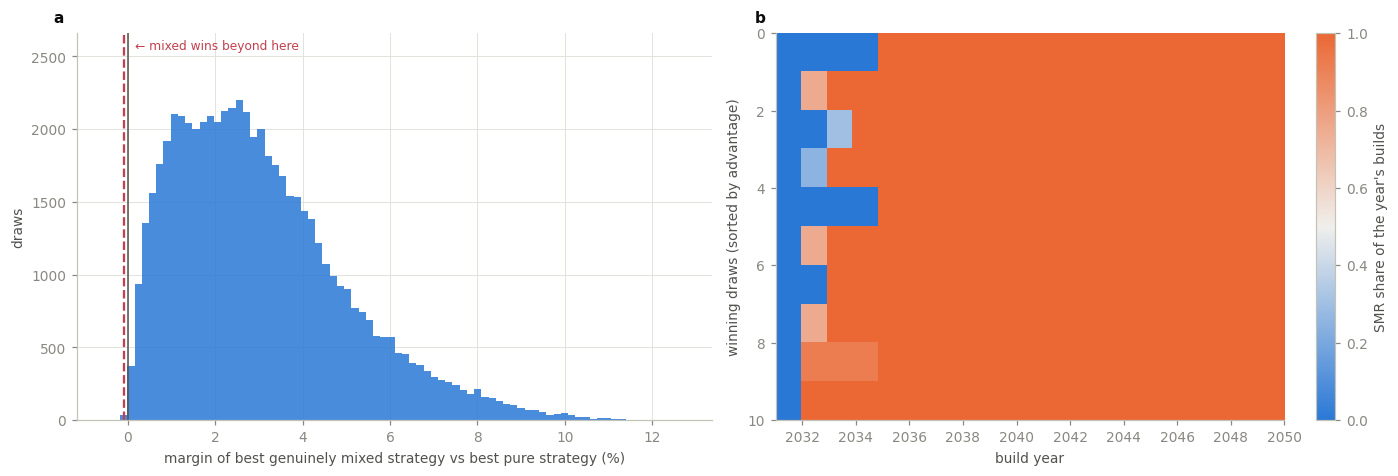

In [18]:
import matplotlib.ticker as mticker

# Figures: the margin distribution (the whole verdict in one panel), and — if any exist —
# the winning share profiles.
fig, axes = plt.subplots(1, 2, figsize=(ps.W3, 4.4))
ax = axes[0]
m_all = 100 * _all["margin"].values
ax.hist(m_all, bins=80, color=ps.ACCENT["blue"], alpha=0.85)
ax.axvline(0.0, color=ps.MUTED, lw=1)
ax.axvline(-100 * TOL_WIN, color=ps.ACCENT["red"], ls="--", lw=1.5)
# Headroom above the tallest bars, then the label just right of the threshold line,
# fully inside the axes (it used to straddle the y-spine at the figure's left edge).
_ymax = ax.get_ylim()[1]
ax.set_ylim(top=_ymax * 1.15)
ax.text(-100 * TOL_WIN + 0.02 * (m_all.max() - m_all.min()), _ymax * 1.13,
        "\u2190 mixed wins beyond here",
        color=ps.ACCENT["red"], fontsize=8, va="top", ha="left")
ax.set_xlabel("margin of best genuinely mixed strategy vs best pure strategy (%)")
ax.set_ylabel("draws")

ax = axes[1]
if len(winning):
    order = winning["advantage"].values.argsort()[::-1]
    heat = winning[[f"p_{y}" for y in BUILD_YEARS]].values[order]
    im = ax.imshow(heat, aspect="auto", cmap=ps.cmap_div(), vmin=0, vmax=1,
                   extent=[BUILD_YEARS[0], BUILD_YEARS[-1], len(winning), 0])
    plt.colorbar(im, ax=ax, label="SMR share of the year's builds")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))  # whole years only
    ax.set_xlabel("build year")
    ax.set_ylabel("winning draws (sorted by advantage)")
    ax.grid(False)
else:
    ax.text(0.5, 0.5, "No mixed-strategy wins\nat the run settings",
            ha="center", va="center", fontsize=13, color=ps.MUTED,
            transform=ax.transAxes)
    ax.set_axis_off()
ps.letter_panels(axes)
plt.tight_layout()
ps.savefig(fig, FIGURES / "mixed_build_advantage.png")
plt.show()

## The parameter space: where each strategy wins

The two orderings make the SMR-vs-large contest two-dimensional: every future has a
**starting-cost gap** (how much more the SMR costs at the 2030 anchor, 2022$/kW) and a
**learning-rate gap** (how much faster it learns). The maps below chart the outcome over that
plane:

1. **Winner maps, one per schedule** — the share of draws in each cell whose cheaper *pure*
   strategy is the SMR program, on the house diverging scale: blue = the large-reactor program
   is the cheaper pure strategy, orange = the SMR program is. The black contour is the 50/50
   decision boundary, and any genuine mixed wins are overplotted as violet stars. Bigger
   schedules amortize the SMR's learning investment over more builds, so the boundary shifts
   with ambition — that shift *is* the deployment-scale effect on technology choice.
2. **Margin map + the closest calls** — **(a)** the mean penalty of the best genuinely mixed
   strategy over the same plane (pooled across schedules), and **(b)** the individual draws
   where the best mixed strategy came within 1% of the best pure one, colored by winner. If
   mixing is ever going to win, these maps show where: the near-ties hug the decision
   boundary, where the two pure programs cost the same and *any* blend of them costs about
   the same too.

saved -> figures\mixed_build_parameter_space.png


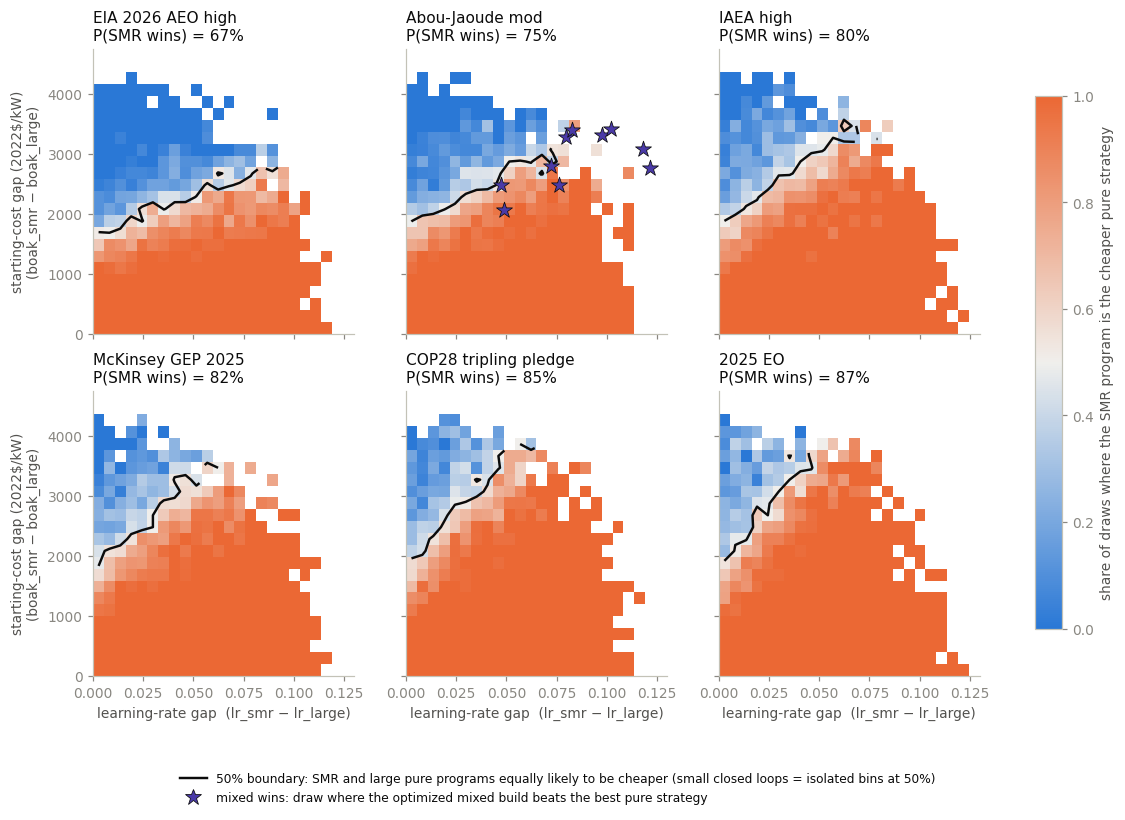

In [19]:
# Winner maps per schedule over the (lr gap, boak gap) plane.
GAP_X_EDGES = np.linspace(0.0, TECH["smr"]["lr_hi"] - TECH["large"]["lr_lo"], 25)
GAP_Y_EDGES = np.linspace(0.0, TECH["smr"]["boak_hi"] - TECH["large"]["boak_lo"], 25)
MIN_BIN = 8                                     # mask cells with fewer draws than this

def binned_rate(df, value_col=None, statistic="mean"):
    """2D binned statistic over (lr_gap, boak_gap); returns (grid, counts)."""
    cnt, _, _ = np.histogram2d(df["lr_gap"], df["boak_gap"], bins=[GAP_X_EDGES, GAP_Y_EDGES])
    if value_col is None:
        return cnt
    tot, _, _ = np.histogram2d(df["lr_gap"], df["boak_gap"], bins=[GAP_X_EDGES, GAP_Y_EDGES],
                               weights=df[value_col].astype(float))
    with np.errstate(invalid="ignore"):
        grid = np.where(cnt >= MIN_BIN, tot / cnt, np.nan)
    return grid, cnt

fig, axes = plt.subplots(2, 3, figsize=(ps.W3, 7.4), sharex=True, sharey=True)
_xc = 0.5 * (GAP_X_EDGES[:-1] + GAP_X_EDGES[1:])
_yc = 0.5 * (GAP_Y_EDGES[:-1] + GAP_Y_EDGES[1:])
for ax, sched in zip(axes.ravel(), SCHED_ORDER):
    df = _all[_all["schedule"] == sched]
    df = df.assign(smr_win=(df["corner_winner"] == "smr").astype(float))
    grid, cnt = binned_rate(df, "smr_win")
    im = ax.pcolormesh(GAP_X_EDGES, GAP_Y_EDGES, grid.T, cmap=ps.cmap_div(),
                       vmin=0, vmax=1, shading="flat")
    masked = np.ma.masked_invalid(grid.T)
    ax.contour(_xc, _yc, masked, levels=[0.5], colors=ps.INK, linewidths=1.6)
    mw = df[df["mixed_wins"]]
    if len(mw):
        ax.scatter(mw["lr_gap"], mw["boak_gap"], marker="*", s=120,
                   c=ps.ACCENT["violet"], edgecolors=ps.INK, lw=0.5, zorder=5)
    p_smr = (df["corner_winner"] == "smr").mean()
    ax.set_title(f"{sched}\nP(SMR wins) = {p_smr:.0%}")
    ax.grid(False)
for ax in axes[1]:
    ax.set_xlabel("learning-rate gap  (lr_smr − lr_large)")
for ax in axes[:, 0]:
    ax.set_ylabel("starting-cost gap (2022$/kW)\n(boak_smr − boak_large)")
fig.colorbar(im, ax=axes, shrink=0.85,
             label="share of draws where the SMR program is the cheaper pure strategy")
# Figure-level key (below the grid, clear of all panels) for the overlay marks:
# the black contour is the 50% line of the plotted SMR-win share; the star marks
# individual draws where the optimized mixed build beats the best pure strategy.
from matplotlib.lines import Line2D
_key = [Line2D([], [], color=ps.INK, lw=1.6,
               label="50% boundary: SMR and large pure programs equally likely to be "
                     "cheaper (small closed loops = isolated bins at 50%)"),
        Line2D([], [], marker="*", ls="none", markersize=11,
               markerfacecolor=ps.ACCENT["violet"], markeredgecolor=ps.INK,
               markeredgewidth=0.5,
               label="mixed wins: draw where the optimized mixed build beats the "
                     "best pure strategy")]
fig.legend(handles=_key, loc="upper center", bbox_to_anchor=(0.45, 0.005),
           frameon=False, fontsize=8, handlelength=2.2, ncol=1)
ps.savefig(fig, FIGURES / "mixed_build_parameter_space.png")
plt.show()

saved -> figures\mixed_build_margin_map.png


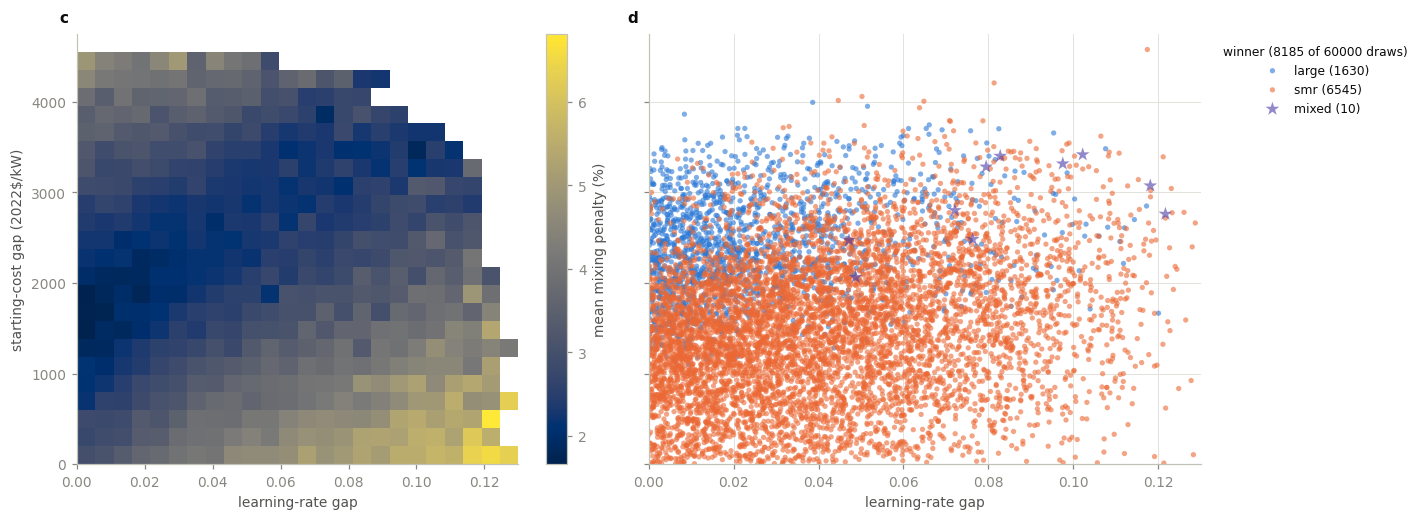

Reading the maps: the near-ties trace the decision boundary — the region where the two pure
programs cost the same, so any blend of them also costs about the same. Mixing gets close
exactly where choosing does not matter, not where mixing creates value.


In [20]:
# The margin map: how expensive is the best possible mix, across the same plane — and the
# individual draws where it came within 1% of the best pure strategy.
fig, axes = plt.subplots(1, 2, figsize=(ps.W3, 4.8), sharex=True, sharey=True)
ax = axes[0]
grid, cnt = binned_rate(_all, "margin")
im = ax.pcolormesh(GAP_X_EDGES, GAP_Y_EDGES, 100 * grid.T, cmap=ps.CMAP_SEQ, shading="flat")
plt.colorbar(im, ax=ax, label="mean mixing penalty (%)")
ax.set_xlabel("learning-rate gap")
ax.set_ylabel("starting-cost gap (2022$/kW)")
ax.grid(False)

ax = axes[1]
close = _all[_all["margin"] < 0.01]
for cat, col, ms in (("large", ps.COL["large"], 12), ("smr", ps.COL["smr"], 12),
                     ("mixed", ps.ACCENT["violet"], 90)):
    sub = close[close["winner"] == cat]
    if len(sub):
        ax.scatter(sub["lr_gap"], sub["boak_gap"], s=ms, c=col, alpha=0.6,
                   marker="*" if cat == "mixed" else "o", edgecolors="none",
                   label=f"{cat} ({len(sub)})")
ax.set_xlabel("learning-rate gap")
# The scatter fills the axes, so park the key outside the right spine, off the data.
ax.legend(fontsize=8, title=f"winner ({len(close)} of {len(_all)} draws)",
          title_fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1.0))
# Letters continue from mixed_build_advantage (a/b): this figure is the second source
# of composed paper figure SF6, so its panels carry c and d.
ps.panel_letter(axes[0], "c")
ps.panel_letter(axes[1], "d")
plt.tight_layout()
ps.savefig(fig, FIGURES / "mixed_build_margin_map.png")
plt.show()
print("Reading the maps: the near-ties trace the decision boundary — the region where the "
      "two pure\nprograms cost the same, so any blend of them also costs about the same. "
      "Mixing gets close\nexactly where choosing does not matter, not where mixing creates value.")

## Sensitivity: shut the spillover off

Re-running the funnel with both cross-technology spillover fractions forced to zero on the same
draws isolates how much the drawn spillover moved mixing toward viability. (This is also the
limiting case the companion notebook's fragmentation figure lives in, which QA-G checks.)

In [21]:
print("cross-tech spillover forced to zero (main draws, all schedules):")
XZERO_FUNNEL = {}
for sched in SCHED_ORDER:
    XZERO_FUNNEL[sched] = run_funnel(WORLDS[sched], sched, S_KV=SKV[sched], x_zero=True,
                                     label=f"xzero/{SCEN_TOKEN[sched]}")
xzero_tab = pd.DataFrame({s: {"P(mixed wins > 0.1%)": float(XZERO_FUNNEL[s]["mixed_wins"].mean()),
                              "closest margin": float(XZERO_FUNNEL[s]["margin"].min())}
                          for s in SCHED_ORDER}).T
xzero_tab.to_csv(EXPORTS / "xzero_verdict.csv")
print()
print(xzero_tab.round(4).to_string())
print("\nComparing 'closest margin' here vs the main run isolates how much the drawn "
      "cross-tech\nspillover moves mixing toward viability.")

cross-tech spillover forced to zero (main draws, all schedules):


  xzero/eia_aeo_high           flagged  307/10000 (near-corner 21, audit-only 286), mixed wins    0 (0.0%), closest margin +0.28%, 98s


  xzero/abou_jaoude            flagged 2945/10000 (near-corner 2736, audit-only 209), mixed wins    6 (0.1%), closest margin -0.37%, 783s


  xzero/iaea_high              flagged  320/10000 (near-corner 0, audit-only 320), mixed wins    0 (0.0%), closest margin +0.54%, 64s


  xzero/mckinsey               flagged  328/10000 (near-corner 0, audit-only 328), mixed wins    0 (0.0%), closest margin +0.53%, 100s


  xzero/cop28                  flagged  291/10000 (near-corner 0, audit-only 291), mixed wins    0 (0.0%), closest margin +0.68%, 92s


  xzero/eo2025                 flagged  301/10000 (near-corner 0, audit-only 301), mixed wins    0 (0.0%), closest margin +0.44%, 104s

                       P(mixed wins > 0.1%)  closest margin
EIA 2026 AEO high                    0.0000          0.0028
Abou-Jaoude mod                      0.0006         -0.0037
IAEA high                            0.0000          0.0054
McKinsey GEP 2025                    0.0000          0.0053
COP28 tripling pledge                0.0000          0.0068
2025 EO                              0.0000          0.0044

Comparing 'closest margin' here vs the main run isolates how much the drawn cross-tech
spillover moves mixing toward viability.


## QA suite

One check per cell, each announcing PASS or FAIL. QA-A/B/D pin this notebook to the companion
notebook's engine at the "off" settings; QA-C validates the ordered draw; QA-E re-pins the
financing port to the ReEDS engine's regression value; QA-F checks the optimizer's internal
consistency; QA-G ties the shared limit (comonotone draw, zero cross-tech spillover - with
x = 0 the engine is exactly the pre-redesign cross-firm form) back to the frozen
pre-redesign fragmentation result.

In [22]:
# QA-A — engine parity: the production experience_channels (with its x_in/S_KV hot-loop
# conveniences at their neutral settings) must reproduce the companion notebook's engine
# BIT-FOR-BIT. The companion's exact function body is pasted here as the reference
# implementation (mc_cost_trajectories.ipynb S5).
def _experience_channels_companion(world, tech, n_us, n_oth=None):
    n = len(world)
    u_r = np.repeat(world["u"].values[:, None], len(REGIONS), axis=1)
    if ONE_FACTOR_DELTA > 0:
        u_r = np.clip(u_r + rng_stream("one_factor_noise").uniform(
            -ONE_FACTOR_DELTA, ONE_FACTOR_DELTA, (n, len(REGIONS))), 0, 1)
    gi = np.clip(np.rint(u_r * (len(U_GRID)-1)).astype(int), 0, len(U_GRID)-1)
    S_kv = np.zeros((n, T))
    for j, r in enumerate(REGIONS):
        S_kv += THETA_KV[r] * REGION_STOCK[r][gi[:, j], :]
    S_kv = lag1(S_kv)
    N_us = lag1(np.broadcast_to(np.asarray(n_us, float), (n, T)))
    conv = world["conv_full"].values[:, None].astype(float)
    m = world["n_vendors"].values[:, None].astype(float)
    s = world["s"].values[:, None]
    hist_us = HIST_UNITS["US"] if tech == "large" else 0.0
    own0 = N_BOAK_UNITS + conv*hist_us/m
    own = own0 + N_us/m
    oth = (m-1.0)*own0 + N_us*(m-1.0)/m \
          + s*(conv*H_ALL_W + S_kv)
    if n_oth is not None:
        x = world[X_IN_COL[tech]].values[:, None]
        oth = oth + x*lag1(np.broadcast_to(np.asarray(n_oth, float), (n, T)))
    return own, oth

_w = WORLDS[REP_SCHED]
for tech in TECH:
    n_us = np.cumsum(GW_ADD[REP_SCHED]) / TECH[tech]["unit_gw"]   # tech takes the whole program
    n_oth = np.cumsum(GW_ADD[REP_SCHED]) / TECH[OTHER_TECH[tech]]["unit_gw"]
    for kwargs in ({}, {"n_oth": n_oth}):
        own_a, oth_a = experience_channels(_w, tech, n_us, **kwargs)      # conveniences off
        own_b, oth_b = experience_channels(_w, tech, n_us, S_KV=SKV[REP_SCHED],
                                           x_in=_w[X_IN_COL[tech]].values, **kwargs)
        own_c, oth_c = _experience_channels_companion(_w, tech, n_us, **kwargs)
        assert np.array_equal(own_a, own_c) and np.array_equal(oth_a, oth_c), \
            (tech, sorted(kwargs))
        assert np.array_equal(own_b, own_c) and np.array_equal(oth_b, oth_c), \
            (tech, sorted(kwargs))
print("QA-A PASSED: production experience_channels reproduces the companion engine bit-for-bit "
      "(with and without a cross-tech program; conveniences off, and explicit-x + cached stock)")

QA-A PASSED: production experience_channels reproduces the companion engine bit-for-bit (with and without a cross-tech program; conveniences off, and explicit-x + cached stock)


In [23]:
# QA-B — anchor identity: OCC(2030) equals the drawn anchor cost for EVERY draw, technology,
# and share profile, even with drawn cross-tech spillover active (the cross-tech stock is
# zero at the anchor by construction, so the anchor can never move).
_rng = rng_stream("mixopt/qa_b")
for sched in SCHED_ORDER:
    w = WORLDS[sched]
    p_full = embed_shares(_rng.random(N_P))
    n_large, n_smr = split_units(sched, p_full)
    for tech, n_own, n_oth, xcol in (("smr", n_smr, n_large, "x_ls"),
                                     ("large", n_large, n_smr, "x_sl")):
        occ = occ_paths_ces(w, tech, n_own, n_oth=n_oth, x_in=w[xcol].values, S_KV=SKV[sched])
        assert np.allclose(occ[:, yi(ANCHOR)], w[f"boak_{tech}"].values), (sched, tech)
print("QA-B PASSED: every draw hits its anchor cost exactly at 2030, "
      "all schedules, both technologies, random share profile, drawn spillover")

QA-B PASSED: every draw hits its anchor cost exactly at 2030, all schedules, both technologies, random share profile, drawn spillover


In [24]:
# QA-C — the ordered draw: both orderings hold on EVERY production draw; the conditioned
# marginals stay inside the published ranges; and the conditioning behaves as expected
# (acceptance ~50%; the SMR marginals tilt up, the large marginals tilt down — reported).
for sched in SCHED_ORDER:
    w = WORLDS[sched]
    assert (w["boak_smr"] > w["boak_large"]).all(), sched
    assert (w["lr_smr"] > w["lr_large"]).all(), sched
    for tech in TECH:
        t = TECH[tech]
        assert w[f"boak_{tech}"].between(t["boak_lo"], t["boak_hi"]).all(), (sched, tech)
        assert w[f"lr_{tech}"].between(t["lr_lo"], t["lr_hi"]).all(), (sched, tech)
_wq = pd.concat([WORLDS[s] for s in SCHED_ORDER], ignore_index=True)
print("QA-C PASSED: boak_smr > boak_large and lr_smr > lr_large on every draw; "
      "all marginals inside their published ranges")
print("conditioning tilt (median of the conditioned marginal vs the unconditioned midpoint):")
for col, lo, hi in (("boak_large", 5250, 7750), ("boak_smr", 5500, 10000),
                    ("lr_large", 0.03, 0.12), ("lr_smr", 0.03, 0.16)):
    mid = 0.5 * (lo + hi)
    print(f"  {col:11s} median {_wq[col].median():8.3f} vs midpoint {mid:8.3f}")

QA-C PASSED: boak_smr > boak_large and lr_smr > lr_large on every draw; all marginals inside their published ranges
conditioning tilt (median of the conditioned marginal vs the unconditioned midpoint):
  boak_large  median 6343.102 vs midpoint 6500.000
  boak_smr    median 8099.589 vs midpoint 7750.000
  lr_large    median    0.065 vs midpoint    0.075
  lr_smr      median    0.115 vs midpoint    0.095


In [25]:
# QA-D — objective consistency: (i) at the corners, the blended program cost equals the
# independently computed pure-technology program score; (ii) the fast single-draw path
# (WorldRow) reproduces the vectorized batch exactly.
for sched in SCHED_ORDER:
    w, skv = WORLDS[sched], SKV[sched]
    w_t = GW_ADD[sched] / DISC
    for tech, p_corner in (("large", np.zeros(N_P)), ("smr", np.ones(N_P))):
        n_us = np.cumsum(GW_ADD[sched]) / TECH[tech]["unit_gw"]
        fc = (occ_paths_ces(w, tech, n_us, S_KV=skv)
              * ccmult_grid(duration_paths(w, tech, n_us), tech) * FIN_REST[tech][None, :])
        direct = fc @ w_t
        blended = program_cost_batch(w, sched, p_corner, S_KV=skv)
        assert np.allclose(direct, blended, rtol=1e-12), (sched, tech)
_rng = rng_stream("mixopt/qa_d")
_w, _skv = WORLDS[REP_SCHED], SKV[REP_SCHED]
for _ in range(20):
    i = int(_rng.integers(len(_w)))
    p = _rng.random(N_P)
    fast = make_draw_objective(_w, i, REP_SCHED, _skv)(p)
    batch = program_cost_batch(_w, REP_SCHED, p, S_KV=_skv)[i]
    assert np.isclose(fast, batch, rtol=1e-12), i
print("QA-D PASSED: corner costs equal the independent pure-technology scores (all schedules), "
      "and the optimizer's fast single-draw path matches the vectorized batch exactly")

QA-D PASSED: corner costs equal the independent pure-technology scores (all schedules), and the optimizer's fast single-draw path matches the vectorized batch exactly


In [26]:
# QA-E — financing regression: the ported IDC multiplier still reproduces the ReEDS learning
# engine's pinned value (nuclear_learning.py self-test: 72 months, 8% nominal, schedule '6').
_ccm = ccmult_from_duration(72.0, 1.08, FIN["sched"]["large"])
assert abs(_ccm - 1.268124) < 1e-5, _ccm
print(f"QA-E PASSED: ccmult(72 mo, 8%, sched '6') = {_ccm:.6f} (ReEDS engine pin: 1.268124)")

QA-E PASSED: ccmult(72 mo, 8%, sched '6') = 1.268124 (ReEDS engine pin: 1.268124)


In [27]:
# QA-F — optimizer internal consistency: polishing can only improve on the screen; every
# winning profile is genuinely mixed; and the random audit sample checks that the free
# optimizer is not finding wins in regions the screen failed to flag.
_missed = 0
for name, fr in list(FUNNEL.items()) + [(f"xzero {s}", XZERO_FUNNEL[s]) for s in SCHED_ORDER]:
    assert (fr["best_mixed"] <= fr["screen"]["best_mixed"] * (1 + 1e-12)).all(), name
    assert np.isfinite(fr["margin"]).all(), name
    if fr["mixed_wins"].any():
        min_share = np.minimum(fr["smr_gw_share"], 1.0 - fr["smr_gw_share"])
        assert (min_share[fr["mixed_wins"]] > 0.01).all(), name
    audit_only = fr["audit"] & ~fr["near"]
    _missed += int((fr["mixed_wins"] & audit_only).sum())
if _missed:
    print(f"QA-F WARNING: {_missed} mixed wins came from audit-only draws the screen did not "
          f"flag — the screening library is too coarse; raise EPS_FLAG or AUDIT_FRAC and rerun.")
else:
    print("QA-F PASSED: polish never worsens the screen, every recorded win is genuinely "
          "mixed, and no mixed win was found on an audit-only draw (the screen flags every "
          "region the optimizer exploits)")

QA-F PASSED: polish never worsens the screen, every recorded win is genuinely mixed, and no mixed win was found on an audit-only draw (the screen flags every region the optimizer exploits)


In [28]:
# QA-G — continuity with the frozen pre-redesign limit this notebook once shared with the
# companion: legacy comonotone draw + zero cross-tech spillover (with x = 0 the engine is
# exactly the pre-redesign cross-firm form - international experience in the cross-firm
# channel, no cross-tech term). The companion's S13 has since moved to the drawn-x engine
# (its printed numbers now include cross-teaching split arms), so the reference here is the
# FROZEN 2026-08-05 figure. Reported, not asserted: different draws and draw counts.
_wg = draw_world_4(min(2000, N_DRAWS_OPT), COPULA_SET, 1.0, rng_stream("mixopt/qa_g"))
_skvg = intl_stock(_wg)
_c_half = program_cost_batch(_wg, REP_SCHED, np.full(N_P, 0.5), S_KV=_skvg, x_zero=True)
_c_corners = np.stack([program_cost_batch(_wg, REP_SCHED, CANDS[nm], S_KV=_skvg, x_zero=True)
                       for nm in ("pure_large", "pure_smr")])
_pen = 100 * (_c_half / _c_corners.min(axis=0) - 1.0)
print("QA-G (report): 50/50-mix penalty at comonotone anchors + zero cross-tech spillover "
      f"(the exact pre-redesign engine), {REP_SCHED}:")
print(f"  this notebook : median {np.percentile(_pen, 50):.1f}%, P90 {np.percentile(_pen, 90):.1f}%, "
      f"negative in {(_pen < 0).mean():.1%} of draws")
print("  frozen 2026-08-05 companion S13: median ~20.2%, P90 ~42% (its own draws and stream) — "
      "same ballpark expected, not asserted")

QA-G (report): 50/50-mix penalty at comonotone anchors + zero cross-tech spillover (the exact pre-redesign engine), McKinsey GEP 2025:


  this notebook : median 17.3%, P90 36.0%, negative in 0.0% of draws
  frozen 2026-08-05 companion S13: median ~20.2%, P90 ~42% (its own draws and stream) — same ballpark expected, not asserted


## Run metadata

In [29]:
import hashlib
import subprocess
from datetime import datetime, timezone

def _sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()[:16]

try:
    _git = subprocess.run(["git", "rev-parse", "HEAD"], cwd=REPO_ROOT,
                          capture_output=True, text=True).stdout.strip()
except Exception:
    _git = "unavailable"

meta = {
    "notebook": "mixed_build_optimizer.ipynb",
    "generated_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "fork_git_head": _git,
    "master_seed": MASTER_SEED,
    "stream_prefix": "mixopt/",
    "draw_design": "independent per-tech (lr, boak) pairs, rejection-conditioned on "
                   "boak_smr > boak_large and lr_smr > lr_large",
    "switches": {"X_SPILL_MAX": X_SPILL_MAX, "HIST_CROSS_TECH": HIST_CROSS_TECH,
                 "COPULA_SET": COPULA_SET, "N_DRAWS_OPT": N_DRAWS_OPT,
                 "EPS_FLAG": EPS_FLAG, "AUDIT_FRAC": AUDIT_FRAC, "TOL_WIN": TOL_WIN,
                 "REP_SCHED": REP_SCHED},
    "headline": {"total_draws": int(total_draws), "total_mixed_wins": int(total_wins),
                 "win_fraction": float(total_wins / total_draws),
                 "closest_margin": float(min(FUNNEL[s]["margin"].min() for s in SCHED_ORDER))},
    "exports": {p.name: _sha256(p) for p in sorted(EXPORTS.glob("*.csv"))},
}
with open(EXPORTS / "mixed_build_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)
print(json.dumps(meta, indent=2))

{
  "notebook": "mixed_build_optimizer.ipynb",
  "generated_utc": "2026-08-17T21:40:47+00:00",
  "fork_git_head": "c0d714ea64d0f85a6334e885793f882aae063057",
  "master_seed": 20260715,
  "stream_prefix": "mixopt/",
  "draw_design": "independent per-tech (lr, boak) pairs, rejection-conditioned on boak_smr > boak_large and lr_smr > lr_large",
  "switches": {
    "X_SPILL_MAX": 0.3,
    "HIST_CROSS_TECH": false,
    "COPULA_SET": "moderate",
    "N_DRAWS_OPT": 10000,
    "EPS_FLAG": 0.005,
    "AUDIT_FRAC": 0.03,
    "TOL_WIN": 0.001,
    "REP_SCHED": "McKinsey GEP 2025"
  },
  "headline": {
    "total_draws": 60000,
    "total_mixed_wins": 10,
    "win_fraction": 0.00016666666666666666,
    "closest_margin": -0.005085963315268005
  },
  "exports": {
    "verdict_by_schedule.csv": "40f82d033263da26",
    "winning_draws.csv": "8b92eaa1584cdc55",
    "xzero_verdict.csv": "b8626ccb8b021edd"
  }
}


## Closing note

The verdict table in S7 is this notebook's deliverable. Read it as the answer to one question:
*granting mixing every advantage we could defend — up to 30% cross-technology spillover in each
direction, independently varying starting-cost and learning-rate gaps (with the SMR always
pricier at the start and always faster-learning), and a per-future optimizer free to choose any
year-by-year technology split — how often, and by how much, does any mixed build program beat
simply committing to the better technology?* The S8 maps place the answer in the parameter
space: they chart where each pure program wins, where the decision boundary runs, and where —
if anywhere — genuinely mixed optima live.

Alongside the companion notebook's fragmentation figure (which prices the 50/50 split under the
paper's baseline conventions), this is the evidence base for the paper's winner-take-all
treatment of the deployment mandate — or, if wins appear above, the precise characterization of
the futures where that treatment would be wrong.